c:\Users\Daniel\interview\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


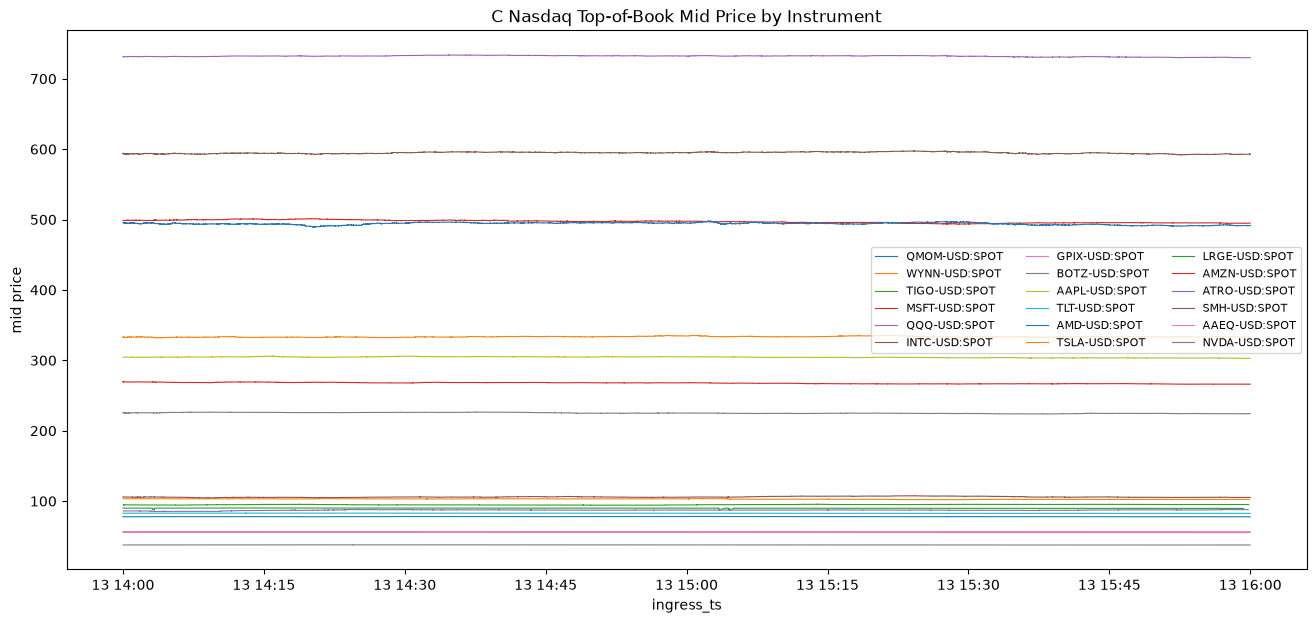

In [2]:
import polars as pl
import matplotlib.pyplot as plt

df = pl.read_parquet("../parquets/C_nasdaq_top_of_book_20_symbols.parquet")

df_plot = (
    df.sort(["instrument", "ingress_ts"])
    .with_columns(mid=(pl.col("bid_price") + pl.col("ask_price")) / 2)
    .select("instrument", "ingress_ts", "mid")
    .drop_nulls()
)

plt.figure(figsize=(16, 7))

for instrument in df_plot["instrument"].unique().to_list():
    x = df_plot.filter(pl.col("instrument") == instrument)
    plt.plot(x["ingress_ts"], x["mid"], linewidth=0.8, label=instrument)

plt.title("C Nasdaq Top-of-Book Mid Price by Instrument")
plt.xlabel("ingress_ts")
plt.ylabel("mid price")
plt.legend(ncol=3, fontsize=8)
plt.show()

In [3]:
df.null_count()

instrument,ingress_ts,transaction_ts,publish_ts,seq_id,bid_price,bid_qty,ask_price,ask_qty
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0


In [4]:
df.sort(["instrument", "seq_id"]).group_by("instrument").agg(
    pl.col("publish_ts").is_sorted().alias("publish_monotonic"),
    pl.col("transaction_ts").is_sorted().alias("transaction_monotonic"),
    pl.col("ingress_ts").is_sorted().alias("ingress_monotonic"),
).select(
    pl.col("publish_monotonic").value_counts().alias("publish_counts"),
    pl.col("transaction_monotonic").value_counts().alias("transaction_counts"),
    pl.col("ingress_monotonic").value_counts().alias("ingress_counts"),
)

publish_counts,transaction_counts,ingress_counts
struct[2],struct[2],struct[2]
"{true,18}","{false,18}","{false,18}"


In [61]:
df.sort(["instrument", "seq_id"]).select(pl.col(["ingress_ts", "transaction_ts", "publish_ts"]).diff().over("instrument").dt.total_microseconds()).unpivot(variable_name="clock", value_name="step_us").group_by("clock").agg((pl.col("step_us") < 0).sum().alias("reversals"), pl.col("step_us").filter(pl.col("step_us") < 0).min().abs().fill_null(0).alias("max_reversal_us"))

clock,reversals,max_reversal_us
str,u32,i64
"""transaction_ts""",44565,218000
"""publish_ts""",0,0
"""ingress_ts""",8169,24


In [62]:
df.select((pl.len() - pl.struct(pl.all()).n_unique()).alias("exact_dupes"), (pl.len() - pl.struct("instrument", "seq_id").n_unique()).alias("instrument_seq_dupes"))

exact_dupes,instrument_seq_dupes
u32,u32
0,0


In [63]:
df.group_by(["instrument", "transaction_ts", "publish_ts", "bid_price", "bid_qty", "ask_price", "ask_qty"]).len().filter(pl.col("len") > 1).sort("len", descending=True)

instrument,transaction_ts,publish_ts,bid_price,bid_qty,ask_price,ask_qty,len
str,"datetime[μs, UTC]","datetime[μs, UTC]",f64,f64,f64,f64,u32
"""SMH-USD:SPOT""",2026-08-13 14:00:43.873 UTC,2026-08-13 14:00:43.873 UTC,593.46,80.0,593.47,40.0,33
"""SMH-USD:SPOT""",2026-08-13 14:00:43.873 UTC,2026-08-13 14:00:43.873 UTC,593.3,120.0,593.47,40.0,24
"""QQQ-USD:SPOT""",2026-08-13 14:01:22.058 UTC,2026-08-13 14:01:22.058 UTC,731.45,280.0,731.47,1120.0,19
"""SMH-USD:SPOT""",2026-08-13 14:00:43.651 UTC,2026-08-13 14:00:43.651 UTC,593.46,80.0,593.48,80.0,18
"""QQQ-USD:SPOT""",2026-08-13 14:07:47.281 UTC,2026-08-13 14:07:47.281 UTC,731.3,280.0,731.33,680.0,18
…,…,…,…,…,…,…,…
"""AMZN-USD:SPOT""",2026-08-13 14:02:39.061 UTC,2026-08-13 14:02:39.061 UTC,269.11,100.0,269.17,100.0,2
"""INTC-USD:SPOT""",2026-08-13 15:28:36.026 UTC,2026-08-13 15:28:36.026 UTC,107.24,500.0,107.26,1000.0,2
"""NVDA-USD:SPOT""",2026-08-13 15:19:54.102 UTC,2026-08-13 15:19:54.102 UTC,224.93,200.0,224.94,100.0,2


In [64]:
df = df.with_columns(capture_latency_us=(pl.col("ingress_ts") - pl.col("publish_ts")).dt.total_microseconds())
df.select(pl.col("capture_latency_us").quantile(q).alias(name) for name, q in [("min_us", 0), ("p50_us", 0.5), ("p95_us", 0.95), ("p99_us", 0.99), ("max_us", 1)])

min_us,p50_us,p95_us,p99_us,max_us
f64,f64,f64,f64,f64
6643.0,87823.0,162745.0,285942.0,2.896027e6


In [65]:
df.filter(pl.col("capture_latency_us") > 1_000_000).group_by(minute=pl.col("ingress_ts").dt.truncate("1m")).agg(pl.len().alias("rows"), pl.col("instrument").n_unique().alias("instruments")).sort("minute")

minute,rows,instruments
"datetime[μs, UTC]",u32,u32
2026-08-13 15:08:00 UTC,71,2
2026-08-13 15:27:00 UTC,16955,17


In [66]:
df = df.with_columns(latency_gt_1s=pl.col("capture_latency_us") > 1_000_000)

In [67]:
df.group_by(minute=pl.col("ingress_ts").dt.truncate("1m")).agg(pl.len().alias("rows"), (pl.col("publish_ts") - pl.col("transaction_ts")).dt.total_microseconds().quantile(0.99).alias("venue_p99_us"), pl.col("capture_latency_us").quantile(0.99).alias("capture_p99_us")).filter((pl.col("minute").dt.hour() == 15) & pl.col("minute").dt.minute().is_between(26, 28)).sort("minute")

minute,rows,venue_p99_us,capture_p99_us
"datetime[μs, UTC]",u32,f64,f64
2026-08-13 15:26:00 UTC,32223,1000.0,198284.0
2026-08-13 15:27:00 UTC,52349,49000.0,2.812814e6
2026-08-13 15:28:00 UTC,46409,1000.0,267407.0


In [68]:
df.with_columns(
    crossed_book=pl.col("bid_price") > pl.col("ask_price"),
    locked_book=pl.col("bid_price") == pl.col("ask_price"),
).select(
    pl.col("crossed_book").sum().alias("crossed_book_count"),
    pl.col("locked_book").sum().alias("locked_book_count"),
)

crossed_book_count,locked_book_count
u32,u32
1030,26814


In [69]:
df.with_columns(
    crossed_book=pl.col("bid_price") > pl.col("ask_price"),
    locked_book=pl.col("bid_price") == pl.col("ask_price"),
).group_by("instrument").agg(
    pl.len().alias("rows"),
    pl.col("crossed_book").sum().alias("crossed_book"),
    pl.col("locked_book").sum().alias("locked_book"),
).with_columns(
    crossed_pct=pl.col("crossed_book") / pl.col("rows") * 100,
    locked_pct=pl.col("locked_book") / pl.col("rows") * 100,
).sort("crossed_book", descending=True)

instrument,rows,crossed_book,locked_book,crossed_pct,locked_pct
str,u32,u32,u32,f64,f64
"""AAPL-USD:SPOT""",326952,233,1359,0.071264,0.415657
"""QQQ-USD:SPOT""",1010088,221,5311,0.021879,0.525796
"""INTC-USD:SPOT""",720879,194,6913,0.026912,0.958968
"""TSLA-USD:SPOT""",168559,158,462,0.093736,0.274088
"""NVDA-USD:SPOT""",618876,96,4226,0.015512,0.682851
…,…,…,…,…,…
"""TIGO-USD:SPOT""",42581,0,0,0.0,0.0
"""WYNN-USD:SPOT""",26827,0,2,0.0,0.007455
"""LRGE-USD:SPOT""",8283,0,0,0.0,0.0


In [70]:
df = df.with_columns(
    crossed_book=pl.col("bid_price") > pl.col("ask_price"),
    locked_book=pl.col("bid_price") == pl.col("ask_price"),
)

In [71]:
df.filter(
    (pl.col("bid_price") <= 0)
    | (pl.col("ask_price") <= 0)
    | (pl.col("bid_qty") <= 0)
    | (pl.col("ask_qty") <= 0)
)

instrument,ingress_ts,transaction_ts,publish_ts,seq_id,bid_price,bid_qty,ask_price,ask_qty,crossed_book,locked_book,mid,spread,spread_pct,spread_outlier,capture_latency_us,latency_gt_1s
str,"datetime[μs, UTC]","datetime[μs, UTC]","datetime[μs, UTC]",i64,f64,f64,f64,f64,bool,bool,f64,f64,f64,bool,i64,bool


In [72]:
df = df.with_columns(
    mid=(pl.col("bid_price") + pl.col("ask_price")) / 2,
    spread=pl.col("ask_price") - pl.col("bid_price"),
)
df = df.with_columns(spread_pct=pl.col("spread") / pl.col("mid") * 100)

df.group_by("instrument").agg(
    pl.col("spread_pct").quantile(0.99).alias("p99_spread_pct"),
    pl.col("spread_pct").max().alias("max_spread_pct"),
)

instrument,p99_spread_pct,max_spread_pct
str,f64,f64
"""AMD-USD:SPOT""",0.129001,0.199482
"""QQQ-USD:SPOT""",0.005478,0.023204
"""TIGO-USD:SPOT""",0.398825,0.791682
"""WYNN-USD:SPOT""",0.223638,0.389143
"""INTC-USD:SPOT""",0.047114,0.161712
…,…,…
"""AAEQ-USD:SPOT""",0.090098,0.469484
"""AMZN-USD:SPOT""",0.029861,0.075047
"""MSFT-USD:SPOT""",0.05,0.093168


In [73]:
df = df.with_columns(
    spread_outlier=pl.col("spread_pct") > pl.col("spread_pct").quantile(0.99).over("instrument")
)
df.group_by("instrument").agg(
    pl.col("spread_outlier").sum().alias("spread_outlier_count")
).sort("spread_outlier_count", descending=True)

instrument,spread_outlier_count
str,u32
"""QQQ-USD:SPOT""",9954
"""INTC-USD:SPOT""",7207
"""NVDA-USD:SPOT""",5968
"""AAPL-USD:SPOT""",3251
"""AMZN-USD:SPOT""",2743
…,…
"""LRGE-USD:SPOT""",83
"""QMOM-USD:SPOT""",68
"""BOTZ-USD:SPOT""",37


In [74]:
df.filter((pl.col("bid_qty") % 10) != 0)

instrument,ingress_ts,transaction_ts,publish_ts,seq_id,bid_price,bid_qty,ask_price,ask_qty,crossed_book,locked_book,mid,spread,spread_pct,spread_outlier,capture_latency_us,latency_gt_1s
str,"datetime[μs, UTC]","datetime[μs, UTC]","datetime[μs, UTC]",i64,f64,f64,f64,f64,bool,bool,f64,f64,f64,bool,i64,bool
